In [ ]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
from google.colab import drive
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)

In [ ]:
# =============================================================================
# SECTION 2: MOUNT GOOGLE DRIVE & EXTRACT DATASET
# =============================================================================
from google.colab import drive
drive.mount('/content/drive')

#zip_path = '/content/drive/MyDrive/ COP528/coursework_task01_imageset.zip'
#extract_to = '/content/drive/MyDrive/ COP528/'
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
# zip_ref.extractall(extract_to)
#print('Extraction complete.')

!ls '/content/drive/MyDrive/ COP528/imageset/train'

Mounted at /content/drive
n01440764  n02979186  n03028079  n03417042  n03445777
n02102040  n03000684  n03394916  n03425413  n03888257


In [ ]:
# =============================================================================
# SECTION 3: CONFIGURATION
# =============================================================================

BATCH_SIZE     = 32
IMG_SIZE       = (144, 144)
IMG_SHAPE      = IMG_SIZE + (3,)  # adds the colour channels dimension
SEED           = 42  # ensures reproducible/random-consistent results

# Scratch CNN epochs
EPOCHS_SCRATCH = 30  # more epochs needed for learnign from scratch

# Transfer learning epochs
EPOCHS_HEAD    = 10  # train classifier head only
EPOCHS_FINE    = 10  # fine-tune pretrained layers


TRAIN_DIR = '/content/drive/MyDrive/ COP528/imageset/train'
VAL_DIR   = '/content/drive/MyDrive/ COP528/imageset/val'

In [ ]:
# =============================================================================
# SECTION 4: LOAD DATASETS
# =============================================================================

train_dataset = image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
)

val_dataset = image_dataset_from_directory(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
)

Found 9468 files belonging to 10 classes.
Found 3925 files belonging to 10 classes.


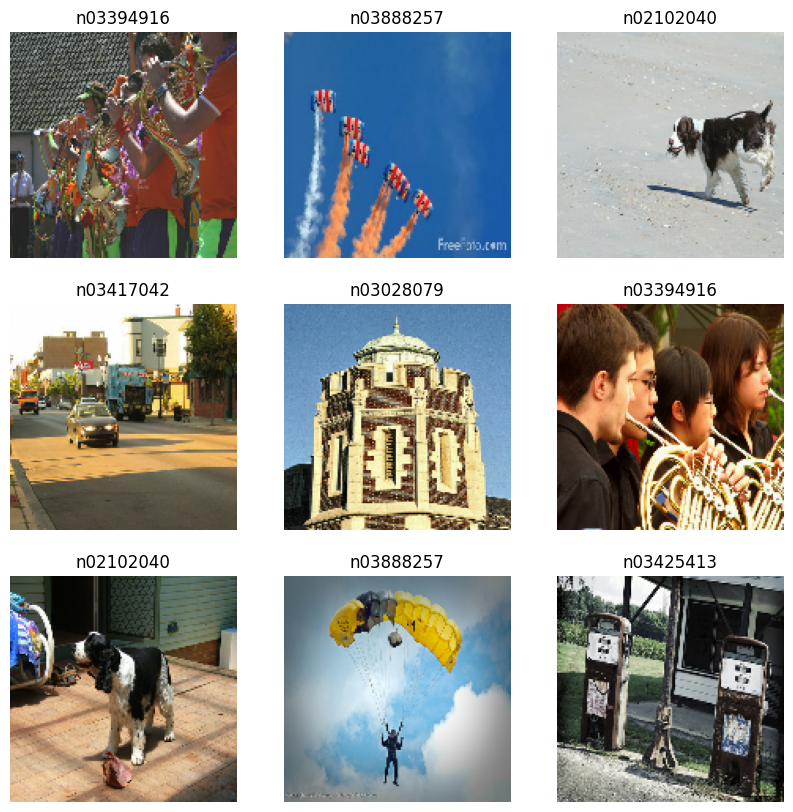

In [ ]:
# =============================================================================
# SECTION 5: VISUALISE SAMPLE IMAGES
# =============================================================================
class_names = train_dataset.class_names
NUM_CLASSES  = len(class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.show()


In [ ]:
# =============================================================================
# SECTION 6: CACHE & PREFETCH
# Code copied from: https://www.tensorflow.org/tutorials/images/classification
# =============================================================================

AUTOTUNE      = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(AUTOTUNE)

In [ ]:
# =============================================================================
# SECTION 7: DATA AUGMENTATION
# Randomly transforms training images to help the model generalise
# Code adapted from: https://www.tensorflow.org/tutorials/images/data_augmentation
# =============================================================================

data_augmentation = tf.keras.Sequential([

    # Simulates objects appearing mirrored
    layers.RandomFlip('horizontal'),

    # accounts for slight camera tilts and objects not perfectly upright
    layers.RandomRotation(0.1),

    # Stimulates objects at varying distances from the camera;
    layers.RandomZoom(0.1),
], name='data_augmentation')


In [ ]:
# =============================================================================
# SECTION 8: SCRATCH CNN — BUILD MODEL
# Custom CNN built from scratch
# Code adapted from: https://www.tensorflow.org/tutorials/images/classification
# Code adapted from: https://medium.com/latinxinai/convolutional-neural-network-from-scratch-6b1c856e1c07
# =============================================================================
scratch_model = tf.keras.Sequential([

    tf.keras.Input(shape=IMG_SHAPE),

    data_augmentation,

    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Block 4
    layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.1),

    # Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')

], name='custom_cnn_scratch')

print(f'\nTotal trainable params: {scratch_model.count_params():,}')
scratch_model.summary()



Total trainable params: 1,244,458


Model: "custom_cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 144, 144, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 144, 144, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 144, 144, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 144, 144, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 144, 144, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 144, 144, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 144, 144, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 144, 144, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 72, 72, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 72, 72, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 36, 36, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,244,458 (4.75 MB)

 Trainable params: 1,242,538 (4.74 MB)

 Non-trainable params: 1,920 (7.50 KB)


Total trainable params: 1,244,458


In [ ]:
# =============================================================================
# SECTION 9: SCRATCH CNN — COMPILE & TRAIN
# Code adapted from: https://www.tensorflow.org/tutorials/images/classification
# Code adapted from: https://keras.io/guides/writing_your_own_callbacks/
# =============================================================================

scratch_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping — stops if val_accuracy stops improving
early_stop_scratch = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

# ReduceLROnPlateau — halves learning rate when training plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ModelCheckpoint — saves best model to Drive automatically
checkpoint_scratch = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/ COP528/scratch_cnn_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print('\n--- Scratch CNN: Training from scratch ---')
history_scratch = scratch_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_SCRATCH,
    callbacks=[early_stop_scratch, reduce_lr, checkpoint_scratch]
)

loss_scratch, acc_scratch = scratch_model.evaluate(val_dataset, verbose=0)
print(f'\nScratch CNN Validation Accuracy: {acc_scratch:.4f}  |  Loss: {loss_scratch:.4f}')



--- Scratch CNN: Training from scratch ---
Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2490 - loss: 2.2351
Epoch 1: val_accuracy improved from None to 0.15847, saving model to /content/drive/MyDrive/ COP528/scratch_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ COP528/scratch_cnn_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 814s 879ms/step - accuracy: 0.2959 - loss: 2.0825 - val_accuracy: 0.1585 - val_loss: 2.7067 - learning_rate: 0.0010
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3650 - loss: 1.8882
Epoch 2: val_accuracy improved from 0.15847 to 0.44688, saving model to /content/drive/MyDrive/ COP528/scratch_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ COP528/scratch_cnn_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.3738 - loss: 1.8691 - val_accuracy: 0.4469 - val_loss: 1.7355 - learning_rate: 0.0010
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.


--- Scratch CNN Classification Report ---
              precision    recall  f1-score   support

   n01440764       0.95      0.81      0.88       387
   n02102040       0.94      0.77      0.85       395
   n02979186       0.80      0.75      0.77       357
   n03000684       0.64      0.63      0.64       386
   n03028079       0.78      0.80      0.79       409
   n03394916       0.89      0.72      0.80       394
   n03417042       0.81      0.88      0.84       389
   n03425413       0.54      0.85      0.66       419
   n03445777       0.87      0.80      0.83       399
   n03888257       0.90      0.85      0.87       390

    accuracy                           0.79      3925
   macro avg       0.81      0.79      0.79      3925
weighted avg       0.81      0.79      0.79      3925



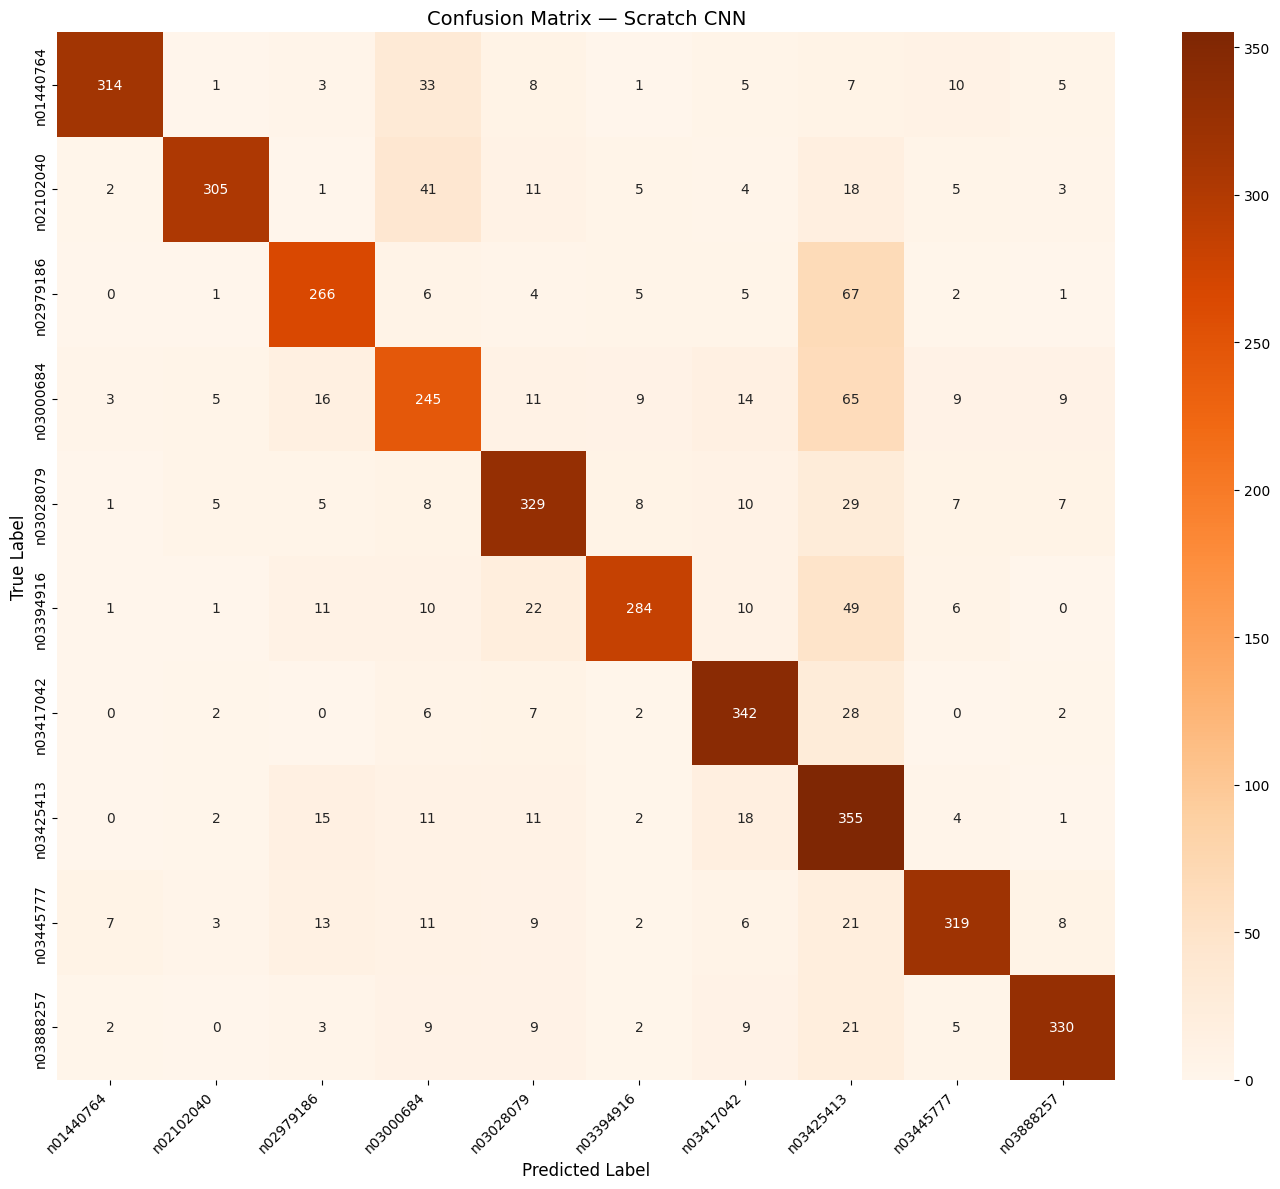

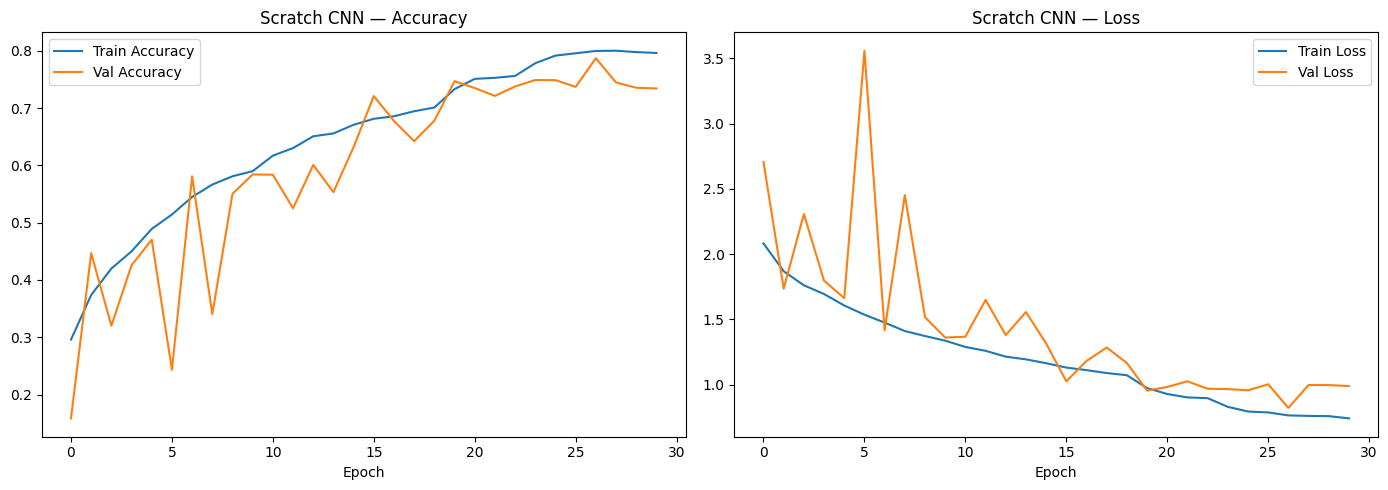

In [ ]:
# =============================================================================
# SECTION 10: SCRATCH CNN — EVALUATION
# Precision, Recall, F1-score per class and confusion matrix
# =============================================================================

y_true_s, y_pred_s = [], []
for images, labels in val_dataset:
    preds = scratch_model.predict(images, verbose=0)
    y_true_s.extend(labels.numpy())
    y_pred_s.extend(np.argmax(preds, axis=1))

y_true_s = np.array(y_true_s)
y_pred_s = np.array(y_pred_s)

print('\n--- Scratch CNN Classification Report ---')
print(classification_report(y_true_s, y_pred_s, target_names=class_names))

# Confusion matrix
cm_scratch = confusion_matrix(y_true_s, y_pred_s)
plt.figure(figsize=(14, 12))
sns.heatmap(cm_scratch, annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names, cmap='Oranges')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix — Scratch CNN', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Training curves
acc_s      = history_scratch.history['accuracy']
val_acc_s  = history_scratch.history['val_accuracy']
loss_s     = history_scratch.history['loss']
val_loss_s = history_scratch.history['val_loss']
epochs_range_s = range(len(acc_s))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_s, acc_s,     label='Train Accuracy')
plt.plot(epochs_range_s, val_acc_s, label='Val Accuracy')
plt.legend(); plt.title('Scratch CNN — Accuracy'); plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_s, loss_s,     label='Train Loss')
plt.plot(epochs_range_s, val_loss_s, label='Val Loss')
plt.legend(); plt.title('Scratch CNN — Loss'); plt.xlabel('Epoch')
plt.tight_layout()
plt.show()